# Modelagem

Nesse notebook iremos testar diversas abordagens de modelagem e iremos escolher a que performar melhor no nosso dataset.

## Importando as Bibliotecas

Primeiro, vamos importar nossas bibliotecas.

In [119]:
import numpy as np
import pandas as pd

## Carregando o Dataset

Agora, vamos carregar o dataset.

In [120]:
df = pd.read_parquet("../data/processed/03_processed.parquet")

In [121]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7919 entries, 0 to 7918
Data columns (total 76 columns):
 #   Column                                 Non-Null Count  Dtype   
---  ------                                 --------------  -----   
 0   tipo_imovel                            7919 non-null   object  
 1   preco                                  7919 non-null   Int64   
 2   condominio                             4602 non-null   Int64   
 3   area_m2                                7919 non-null   Int64   
 4   quartos                                7918 non-null   Int64   
 5   banheiros                              7918 non-null   Int64   
 6   vagas                                  7286 non-null   Int64   
 7   piscina                                7919 non-null   boolean 
 8   espaco_gourmet                         7919 non-null   boolean 
 9   academia                               7919 non-null   boolean 
 10  spa_massagem                           7919 non-null   boolean 
 11  es

In [118]:
df.head(10)

,tipo_imovel,preco,condominio,area_m2,quartos,banheiros,vagas,piscina,espaco_gourmet,academia,...,m2_por_banheiro,m2_por_quarto,banheiros_por_m2,quartos_por_m2,banheiro_por_quarto,quarto_por_vaga,vaga_por_banheiro,area_m2_log,condominio_log,cluster
0,apartamento,350000,720,60,2,2,1,True,True,True,...,30.000000,30.000000,0.033333,0.033333,1.000000,2.00,0.500000,4.110874,6.580639,4
1,apartamento,511914,<NA>,37,1,1,1,True,True,True,...,37.000000,37.000000,0.027027,0.027027,1.000000,1.00,1.000000,3.637586,NaN,1
2,apartamento,980000,1037,125,3,5,2,True,True,False,...,25.000000,41.666667,0.040000,0.024000,1.666667,1.50,0.400000,4.836282,6.945051,1
3,apartamento,2799000,1200,244,3,4,4,True,True,True,...,61.000000,81.333333,0.016393,0.012295,1.333333,0.75,1.000000,5.501258,7.090910,14
4,apartamento,370000,460,57,2,2,1,True,True,True,...,28.500000,28.500000,0.035088,0.035088,1.000000,2.00,0.500000,4.060443,6.133398,11
5,apartamento,499000,<NA>,55,2,2,1,True,True,True,...,27.500000,27.500000,0.036364,0.036364,1.000000,2.00,0.500000,4.025352,NaN,7
6,apartamento,195000,350,52,1,1,<NA>,True,True,True,...,52.000000,52.000000,0.019231,0.019231,1.000000,NaN,NaN,3.970292,5.860786,8
7,apartamento,1210314,<NA>,128,3,3,2,True,True,True,...,42.666667,42.666667,0.023438,0.023438,1.000000,1.50,0.666667,4.859812,NaN,1
8,apartamento,860000,880,105,3,4,2,True,True,True,...,26.250000,35.000000,0.038095,0.028571,1.333333,1.50,0.500000,4.663439,6.781058,1
9,apartamento,400000,400,55,2,2,1,True,True,True,...,27.500000,27.500000,0.036364,0.036364,1.000000,2.00,0.500000,4.025352,5.993961,7


In [30]:
df["tipo_imovel"] = df["tipo_imovel"].astype("category")

In [ ]:
boolean_columns = df.select_dtypes(include="boolean").columns.to_list()


## Divisão Treino-Teste

Nessa etapa de modelagem faremos otimização de hiperparâmetros dos nossos modelos e para checarmos a qualidade final do modelo iremos testâ-lo em dados de teste. Para isso precisamos dividir os dados de treinamento e de teste.

In [73]:
from sklearn.model_selection import train_test_split

X = df.drop("preco", axis="columns")
y = df["preco"]

random_state = 1668

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.7,
    random_state=random_state,
)

## Regressão Linear com Regularização L1 (Lasso)

O primeiro modelo que iremos treinar é o modelo de Regressão Linear com Regularização L1, também conhecida como Lasso, sendo esse modelo o nosso baseline. Faremos a otimização de hiperparâmetros desse modelo usando a Validação Cruzada com 5 folds e usando a biblioteca `Optuna`.

In [96]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
)
from sklearn.compose import (
    ColumnTransformer,
    TransformedTargetRegressor,
)
from sklearn.model_selection import (
    KFold,
    cross_val_score,
    cross_validate,
)
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline


kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=random_state,
)

numeric_columns = X_train.select_dtypes(include="number").columns.to_list()
categorical_columns = ["tipo_imovel", "cluster"]
ordinal_columns = ["faixa_area", "faixa_condominio"]

def get_elastic_net_pipeline(parameters):
    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler())
    ])

    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
    ])

    ordinal_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_columns),
            ("categorical", categorical_pipeline, categorical_columns),
            ("ordinal", ordinal_pipeline, ordinal_columns),
        ],
        remainder="passthrough",
    )
    
    regressor = ElasticNet(
        alpha=parameters["alpha"],
        l1_ratio=parameters["l1_ratio"],
        max_iter=10000,
        random_state=random_state,
    )

    transformer = PowerTransformer()

    model = TransformedTargetRegressor(
        regressor=regressor,
        transformer=transformer,
    )

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    return pipeline


def objective_elastic_net(trial):
    pipeline = get_elastic_net_pipeline({
        "alpha": trial.suggest_float("alpha", 1e-4, 100.0, log=True),
        "l1_ratio": trial.suggest_float("l1_ratio", 0.01, 0.99),
    })

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=kfold,
        scoring="neg_mean_absolute_error",
    )

    return scores.mean()

In [117]:
pipeline = get_elastic_net_pipeline({"alpha": 1.0, "l1_ratio": 0.5})
print(pd.DataFrame(pipeline.named_steps["preprocessor"].fit_transform(X_train)).astype(float).describe().to_string())

                 0            1            2            3            4            5            6            7            8            9            10           11           12           13           14           15           16           17           18           19           20           21           22           23           24           25           26           27           28           29           30           31           32           33           34           35           36           37           38           39           40           41           42           43           44           45           46           47           48           49           50           51           52           53           54           55           56           57           58           59           60           61           62           63           64           65           66           67           68           69           70           71           72           73           74           75      

Agora que montamos nossa função objetivo, vamos criar nosso estudo e executar a otimização de hiperparâmetros.

In [97]:
import optuna

study = optuna.create_study(
    direction="maximize",
)

study.optimize(
    objective_elastic_net,
    n_trials=10,
    show_progress_bar=True,
)

[I 2026-08-20 00:31:26,864] A new study created in memory with name: no-name-e11110a2-b957-4f7c-9816-474c9bf900e1
  0%|          | 0/10 [00:00<?, ?it/s]/home/gauloish/.dev/ds/projects/meu-ape/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_data.py:3543: UserWarning: Some values in column 0 of the inverse-transformed data are NaN. This may be caused by numerical issues in the transformation process, e.g. extremely skewed data. Consider inspecting the input data or preprocessing it before applying the transformation.
  warnings.warn(
/home/gauloish/.dev/ds/projects/meu-ape/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:974: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/gauloish/.dev/ds/projects/meu-ape/.venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 167, in __call__
    score = scorer._score(
            ^^^^^^

[W 2026-08-20 00:31:27,594] Trial 0 failed with parameters: {'alpha': 0.24454127255728464, 'l1_ratio': 0.32884834498332005} because of the following error: The value nan is not acceptable.
[W 2026-08-20 00:31:27,596] Trial 0 failed with value np.float64(nan).


Best trial: 1. Best value: -392785:  20%|██        | 2/10 [00:01<00:06,  1.18it/s]

[I 2026-08-20 00:31:28,519] Trial 1 finished with value: -392784.90399932367 and parameters: {'alpha': 0.00884278807165683, 'l1_ratio': 0.712953314215224}. Best is trial 1 with value: -392784.90399932367.


Best trial: 2. Best value: -392332:  30%|███       | 3/10 [00:02<00:05,  1.18it/s]

[I 2026-08-20 00:31:29,368] Trial 2 finished with value: -392332.35118382773 and parameters: {'alpha': 0.008069529202446853, 'l1_ratio': 0.8431341270276587}. Best is trial 2 with value: -392332.35118382773.


Best trial: 2. Best value: -392332:  30%|███       | 3/10 [00:05<00:12,  1.80s/it]


[W 2026-08-20 00:31:32,246] Trial 3 failed with parameters: {'alpha': 0.000295239086026271, 'l1_ratio': 0.3161767773108059} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/gauloish/.dev/ds/projects/meu-ape/.venv/lib/python3.12/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_203431/2212504041.py", line 85, in objective_elastic_net
    scores = cross_val_score(
             ^^^^^^^^^^^^^^^^
  File "/home/gauloish/.dev/ds/projects/meu-ape/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/home/gauloish/.dev/ds/projects/meu-ape/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 650, in cross_val_score
    cv_results = cross_validate(
                 ^^^^^^^^^^^^^^^
  File "/home/gaulo

KeyboardInterrupt: 

In [84]:
print(f"Best R^2: {study.best_value}")

Best R^2: -382394.88481676043


In [85]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    root_mean_squared_error,
    mean_absolute_percentage_error,
)

pipeline = get_elastic_net_pipeline(study.best_params)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("========== Lasso Metrics ==========")
print(f"R^2:  {r2_score(y_test, y_pred)}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred)}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred)}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred)}")

========== Lasso Metrics ==========
R^2:  -2.178746728151308
MAE:  416369.770037591
RMSE: 2460963.9570734357
MAPE: 0.2731533725045016


In [86]:
(y_test - y_pred).mean()

np.float64(41840.09378680352)

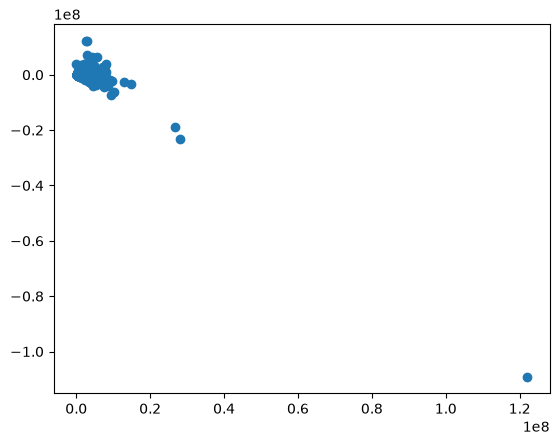

In [90]:
import matplotlib.pyplot as plt

plt.scatter(x=y_pred, y=(y_test-y_pred))
plt.show()

(array([369., 845., 282., 150., 193., 145.,  79.,  44.,  37.,  21.,  26.,
         20.,  34.,  17.,  29.,   9.,  17.,   6.,  13.,   5.,   5.,   2.,
          1.,   3.,   0.,   0.,   1.,   5.,   0.,   2.,   2.,   5.,   0.,
          2.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,
          2.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   2.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([  213620.31325036,   443482.5869338 ,   673344.86061723,
          903207.13430067,  1133069.4079841 ,  1362931.68166753,
         1592793.95535097,  1822656.2290344 ,  2052518.50271784,
         2282380.77640127,  2512243.05008471,  2742105.32376814,
         2971967.59745158,  3201829.87113501,  3431692.144

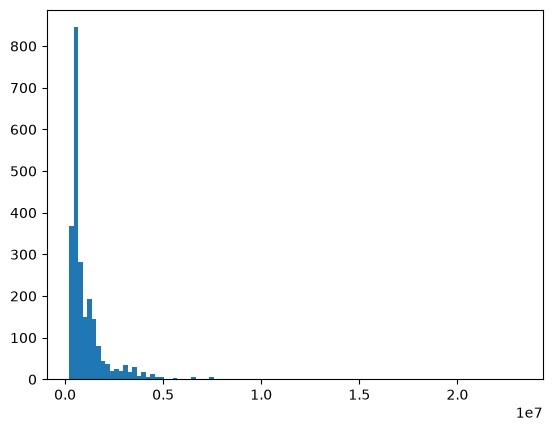

In [70]:
plt.hist(y_pred, bins=100)

(array([ 29., 266., 504., 395., 267., 127., 138., 113.,  66.,  69.,  56.,
         37.,  27.,  30.,  25.,  20.,  20.,  20.,  23.,   6.,  21.,   7.,
         10.,  11.,   6.,   6.,   7.,   2.,   6.,   2.,   1.,   1.,   2.,
          1.,   1.,   0.,   6.,   0.,   4.,   3.,   4.,   1.,   3.,   1.,
          2.,   2.,   5.,   0.,   0.,   0.,   0.,   0.,   2.,   0.,   0.,
          2.,   0.,   0.,   4.,   0.,   0.,   0.,   1.,   0.,   1.,   0.,
          0.,   0.,   2.,   1.,   2.,   1.,   0.,   0.,   0.,   1.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          4.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,
          1.]),
 array([   49000.,   218510.,   388020.,   557530.,   727040.,   896550.,
         1066060.,  1235570.,  1405080.,  1574590.,  1744100.,  1913610.,
         2083120.,  2252630.,  2422140.,  2591650.,  2761160.,  2930670.,
         3100180.,  3269690.,  3439200.,  3608710.,  3778220.,  3947730.,
         4117240.,  42

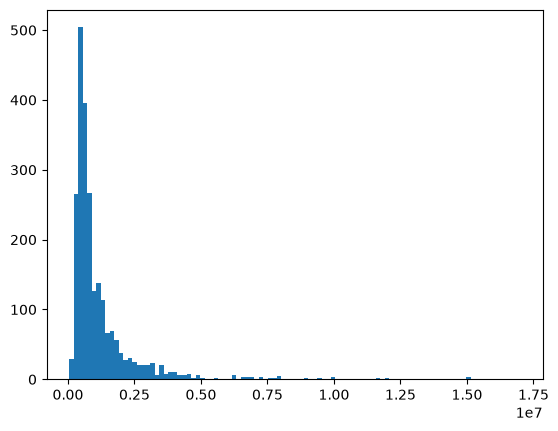

In [71]:
plt.hist(y_test, bins=100)

In [72]:
pipeline.named_steps["model"].coef_

AttributeError: 'TransformedTargetRegressor' object has no attribute 'coef_'